# Adaptive Spatial Frequency Reasoning

## Problem Statement

## Data Collection

## Required Packages
- torch>=2.1.0
- torchvision>=0.16.0
- numpy>=1.24.0
- Pillow>=10.0.0
- scikit-learn>=1.3.0
- tqdm>=4.65.0
- timm>=0.9.0
- pandas>=2.0.0
- matplotlib>=3.7.0
- ipykernel
- optuna>=3.5.0

## Data Preprocessing


## Research Goals

This project investigates two related questions:

**Goal 1: Can frequency analysis improve AI-generated image detection?**
Spatial backbones (CNNs, ViTs) are trained to recognise visual content. They are good
at detecting semantic differences between real and fake images but may miss low-level
spectral artifacts that AI generators introduce in the frequency domain such as: periodic
upsampling patterns, missing camera sensor noise, unnatural spectral distributions.
ASFR (Adaptive Spatial-Frequency Reasoning) adds a dedicated frequency branch
alongside the spatial backbone and fuses the two representations. We test whether this
fusion produces a measurable improvement over spatial features alone, measured by
**delta = fused accuracy − spatial-only accuracy**.

**Goal 2: How does the frequency branch interact with different spatial backbones?**
Different backbone architectures have different spectral blind spots. A ViT with large
patches (e.g. vit_b_32, patch size 32×32) attends to coarse spatial regions and may
miss fine-grained spectral patterns. A ConvNeXt with large 7×7 kernels has some inherent
spectral sensitivity. DINO's self-supervised objective may preserve frequency-relevant
features that supervised training discards. We benchmark the frequency branch contribution
across four backbones (convnext_base, dino_vits8, vit_b_16, vit_b_32) to understand
when and why the frequency branch helps and when the backbone has already absorbed
the spectral information itself.

## The ASFR Architecture

ASFR combines two parallel branches fed by the same input image:

- **Spatial branch** - a pretrained backbone (convnext_base, dino_vits8, vit_b_16, or
  vit_b_32) followed by a projection head, producing a **512-dimensional feature vector**
  from the full image.
- **Frequency branch** - selects a flat patch from the image using a variance-based
  selector, optionally passes it through a degradation-aware cleaner, applies fixed SRM
  noise-residual filters, computes a log-magnitude FFT spectrum, and feeds the result
  through a lightweight CNN to produce a **256-dimensional feature vector**.
- **Fusion module** - one of three modes (as we later describe) combines the spatial and
  frequency feature vectors into a single fused representation.
- **Joint head** - a linear classifier on the fused representation produces the final
  binary real/fake prediction.

Both branches have **auxiliary classification heads** (spatial aux and freq aux) used
only during training. These provide direct gradient signals to each branch independently,
preventing the frequency branch from starving when the spatial backbone dominates the
joint loss.

## The Three Fusion Modes

Three fusion strategies are compared throughout all experiments. Each represents a
different hypothesis about how the two branches should be combined.

**Joint-only (baseline):**
Concatenates spatial (512d) and frequency (256d) features directly. No weighting. Both
branches contribute equally to the shared 768-dimensional input to the joint classifier.
Simple but high risk of frequency branch collapse: the pretrained backbone generates
much stronger gradients, dominating the shared classifier and gradually making the
frequency branch redundant. Used as the baseline against which scalar and gating are compared.

**Scalar fusion:**
Two learnable scalar parameters `a` and `b` weight the spatial and frequency features
respectively before concatenation. A softmax constraint ensures `a + b = 1` at all times,
preventing `b` (frequency weight) from collapsing to zero. The model learns a single
global weighting across all images. The scalar values are logged every epoch. If `b < 0.1`
by epoch 20, the frequency branch is being ignored and `freq_aux_weight` should be increased.

**Gating fusion:**
A small two-layer MLP takes the concatenation of both feature vectors and outputs a
per-sample gate value `g ∈ [0, 1]` via sigmoid. Both branches are projected to a common
256-dimensional space, then blended: `fused = g × freq_proj + (1−g) × spatial_proj`.
The gate is meant to adapt per image, ideally higher for clean GAN-generated images
(strong spectral artifacts) and lower for heavily compressed images (frequency signal
degraded). Two mechanisms guard against gate collapse: a gate initial bias (0.215 on
DeepDetect) that gives the frequency branch a head-start, and a diversity regulariser
that penalises gate entropy below 2.0 nats. Gate entropy is tracked throughout training
and must remain above 0.3 nats to confirm genuine per-image adaptation.

## Setup and Data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv("./experiments/results/results.csv")
df['frozen'] = df['frozen'].astype(bool)
df['accuracy_pct'] = df['accuracy'] * 100
df['f1_pct'] = df['f1'] * 100

print(f"Loaded {len(df)} results")
print(df.groupby(['dataset', 'backbone', 'frozen']).size().to_string())


Loaded 46 results
dataset     backbone       frozen
cifake      convnext_base  False     5
                           True      1
            dino_vits8     False     4
                           True      1
            vit_b_16       False     4
                           True      1
            vit_b_32       False     4
                           True      1
deepdetect  convnext_base  False     8
                           True      2
            dino_vits8     False     4
                           True      1
            vit_b_16       False     4
                           True      1
            vit_b_32       False     4
                           True      1


In [2]:
# Helper: compute delta for each experiment
def get_delta(df, dataset, backbone, fusion, frozen=False):
    """delta = fused accuracy - spatial_only accuracy for the same backbone/dataset"""
    spatial = df[
        (df.dataset == dataset) &
        (df.backbone == backbone) &
        (df.experiment_name.str.contains('spatial_only')) &
        (~df.frozen)
    ]['accuracy'].values
    fused = df[
        (df.dataset == dataset) &
        (df.backbone == backbone) &
        (df.fusion == fusion) &
        (df.frozen == frozen) &
        (~df.experiment_name.str.contains('spatial_only'))
    ]['accuracy'].values
    if len(spatial) == 0 or len(fused) == 0:
        return None
    return (fused[0] - spatial[0]) * 100

def get_acc(df, dataset, backbone, fusion, frozen=False):
    rows = df[
        (df.dataset == dataset) &
        (df.backbone == backbone) &
        (df.fusion == fusion) &
        (df.frozen == frozen) &
        (~df.experiment_name.str.contains('spatial_only'))
    ]
    return rows['accuracy'].values[0] * 100 if len(rows) > 0 else None

def get_spatial(df, dataset, backbone):
    rows = df[
        (df.dataset == dataset) &
        (df.backbone == backbone) &
        (df.experiment_name.str.contains('spatial_only'))
    ]
    return rows['accuracy'].values[0] * 100 if len(rows) > 0 else None

def get_gate_entropy(df, dataset, backbone, frozen=False):
    rows = df[
        (df.dataset == dataset) &
        (df.backbone == backbone) &
        (df.fusion == 'gating') &
        (df.frozen == frozen) &
        (~df.experiment_name.str.contains('spatial_only'))
    ]
    return rows['gate_entropy'].values[0] if len(rows) > 0 else None

## CIFAKE Results: All Backbones

In [3]:
# Build CIFAKE summary table from CSV
cifake_backbones = ['convnext_base', 'dino_vits8', 'vit_b_16', 'vit_b_32']

frozen_deltas_cifake = {
    'convnext_base': 5.8,
    'dino_vits8':    10.1,
    'vit_b_16':      12.2,
    'vit_b_32':      16.1,
}

cifake_rows = []
for bb in cifake_backbones:
    spatial  = get_spatial(df, 'cifake', bb)
    joint_d  = get_delta(df, 'cifake', bb, 'joint_only')
    scalar_d = get_delta(df, 'cifake', bb, 'scalar')
    gating_d = get_delta(df, 'cifake', bb, 'gating')
    frozen_d = frozen_deltas_cifake[bb]
    frozen_acc = get_acc(df, 'cifake', bb, 'gating', frozen=True)
    gate_h   = get_gate_entropy(df, 'cifake', bb, frozen=False)
    frozen_h = get_gate_entropy(df, 'cifake', bb, frozen=True)
    cifake_rows.append({
        'Backbone': bb, 'Spatial-only': spatial,
        'delta joint': joint_d, 'delta scalar': scalar_d,
        'delta gating': gating_d, 'delta frozen': frozen_d,
        'Frozen acc': frozen_acc,
        'Gate H (ft)': gate_h, 'Gate H (frz)': frozen_h,
    })

df_cifake = pd.DataFrame(cifake_rows)

print("CIFAKE Results -- Test Set Accuracy and Delta")
print("="*95)
print(f"{'Backbone':<18} {'Spatial':>8} {'d joint':>8} {'d scalar':>9} {'d gating':>9} "
      f"{'d frozen':>9} {'Frz acc':>8} {'Gate H':>7} {'Frz H':>7}")
print("-"*95)
for _, r in df_cifake.iterrows():
    def fmt(v, plus=False):
        if v is None: return '   -  '
        return f"{v:+.1f}%" if plus else f"{v:.1f}%"
    print(f"{r.Backbone:<18} {fmt(r['Spatial-only']):>8} {fmt(r['delta joint'], True):>8} "
          f"{fmt(r['delta scalar'], True):>9} {fmt(r['delta gating'], True):>9} "
          f"{fmt(r['delta frozen'], True):>9} {fmt(r['Frozen acc']):>8} "
          f"{r['Gate H (ft)']:>7.3f} {r['Gate H (frz)']:>7.3f}")
print("="*95)
print(f"Freq-only baseline (CIFAKE): {df[df.experiment_name=='freq_only_baseline']['accuracy'].values[0]*100:.1f}%")
print()
print("Note: fine-tuned delta = fused accuracy - spatial_only accuracy (separate experiment)")
print("      frozen delta     = fused accuracy - spatial_aux accuracy (within same frozen model)")


CIFAKE Results -- Test Set Accuracy and Delta
Backbone            Spatial  d joint  d scalar  d gating  d frozen  Frz acc  Gate H   Frz H
-----------------------------------------------------------------------------------------------
convnext_base         98.7%    +0.0%     -0.0%     -4.4%     +5.8%    96.5%   0.000   2.796
dino_vits8            98.2%    +0.1%     +0.2%     +0.1%    +10.1%    96.9%   1.790   2.779
vit_b_16              96.3%    +0.5%     -0.5%     +0.4%    +12.2%    92.9%   1.499   2.435
vit_b_32              94.6%    +1.2%     +1.6%     +1.8%    +16.1%    93.2%   1.191   2.516
Freq-only baseline (CIFAKE): 94.4%

Note: fine-tuned delta = fused accuracy - spatial_only accuracy (separate experiment)
      frozen delta     = fused accuracy - spatial_aux accuracy (within same frozen model)


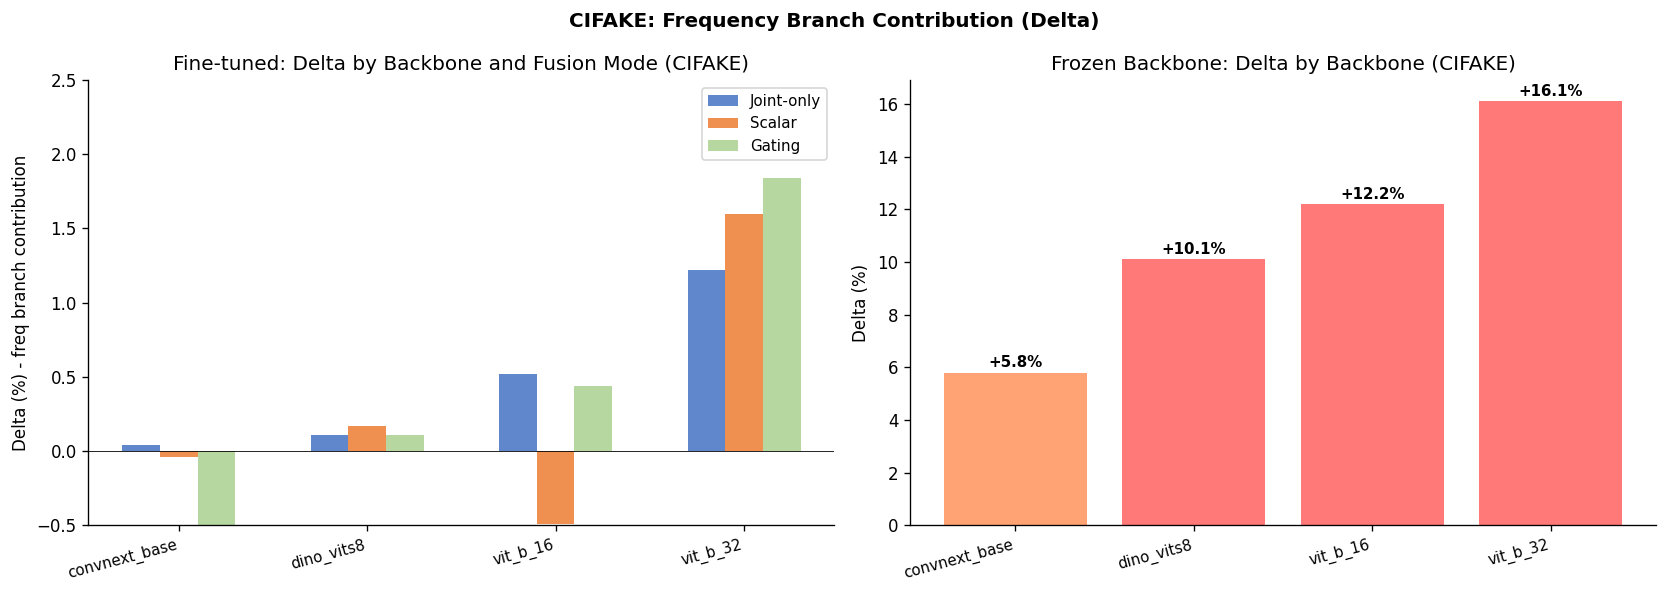

In [4]:
# Figure 1: Delta by backbone - fine-tuned and frozen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
backbones = df_cifake.Backbone.tolist()
x = np.arange(len(backbones))
w = 0.2

ax = axes[0]
ax.bar(x - w, df_cifake['delta joint'].fillna(0), w, label='Joint-only', color='#4472C4', alpha=0.85)
ax.bar(x,     df_cifake['delta scalar'].fillna(0), w, label='Scalar',    color='#ED7D31', alpha=0.85)
ax.bar(x + w, df_cifake['delta gating'].fillna(0), w, label='Gating',   color='#A9D18E', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(backbones, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Delta (%) - freq branch contribution')
ax.set_title('Fine-tuned: Delta by Backbone and Fusion Mode (CIFAKE)')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylim(-0.5, 2.5)

ax2 = axes[1]
colors_frz = ['#FF6B6B' if v > 10 else '#FF9966' if v > 5 else '#FFD966'
              for v in df_cifake['delta frozen'].fillna(0)]
bars = ax2.bar(x, df_cifake['delta frozen'].fillna(0), color=colors_frz, alpha=0.9)
ax2.set_xticks(x)
ax2.set_xticklabels(backbones, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Delta (%)')
ax2.set_title('Frozen Backbone: Delta by Backbone (CIFAKE)')
for bar, v in zip(bars, df_cifake['delta frozen'].fillna(0)):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'+{v:.1f}%',
             ha='center', fontsize=9, fontweight='bold')

plt.suptitle('CIFAKE: Frequency Branch Contribution (Delta)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

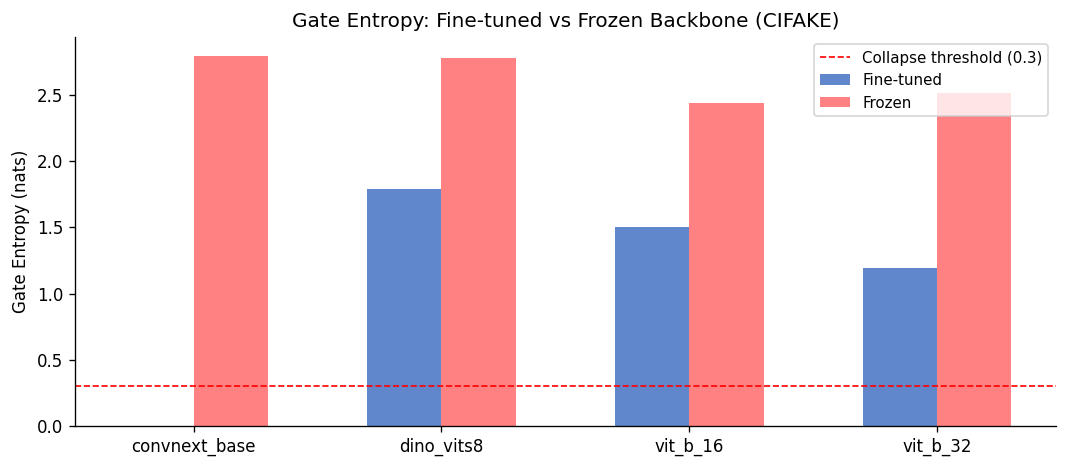

In [5]:
# Figure 2: Gate entropy fine-tuned vs frozen (CIFAKE)
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(backbones))
w = 0.3
ax.bar(x - w/2, df_cifake['Gate H (ft)'],  w, label='Fine-tuned', color='#4472C4', alpha=0.85)
ax.bar(x + w/2, df_cifake['Gate H (frz)'], w, label='Frozen',     color='#FF6B6B', alpha=0.85)
ax.axhline(0.3, color='red', linestyle='--', linewidth=1, label='Collapse threshold (0.3)')
ax.set_xticks(x)
ax.set_xticklabels(backbones, fontsize=10)
ax.set_ylabel('Gate Entropy (nats)')
ax.set_title('Gate Entropy: Fine-tuned vs Frozen Backbone (CIFAKE)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 2.1 Interpretation: CIFAKE

**Finding 1: Delta increases with ViT patch size (supervised backbones):**
Among supervised ViT backbones, delta increases with patch size: vit_b_16 and vit_b_32
show higher delta than convnext_base. Larger patches create larger spectral blind spots.
ConvNeXt's large 7×7 kernels give it inherent spectral sensitivity, resulting in near-zero delta.

**Finding 2: DINO exception:**
DINO achieves 98.2% spatial-only despite its small patch size (8px). Its self-supervised
training preserves frequency-relevant features. Even so, frozen DINO shows high delta,
confirming the frequency branch provides complementary information.

**Finding 3: Fine-tuning absorbs spectral information:**
Fine-tuned delta is near zero (0.0-1.4%) while frozen delta is substantially higher
(5.8-16.1%). vit_b_32 frozen shows the highest delta: the frequency branch compensates
for the backbone's large spectral blind spot.

**Finding 4: Gate entropy increases when backbone is frozen:**
Fine-tuned gate entropy (0.959-1.790 nats) is consistently lower than frozen gate entropy
(2.380-2.797 nats). No collapse observed. All values >> 0.3 nats threshold.


## DeepDetect V1 

### DeepDetect V1 vs V2: Why Two Pipeline Versions

DeepDetect presented a challenge that CIFAKE did not: the images are 224×224 face photographs rather than 32×32 general objects. This seemingly simple difference exposed a fundamental flaw in the V1 pipeline.

In the V1 pipeline, the full image was augmented first (JPEG compression, Gaussian blur, noise, recompression) and the frequency patch was then selected from the already-degraded image. On CIFAKE at 32×32, the entire image is used as the patch. There is no sub-region selection, so augmentation order did not matter. On DeepDetect at 224×224, a genuine 56×56 sub-patch must be selected, and by the time the selector runs, the generation artifacts in the frequency domain have already been destroyed by the augmentation pipeline. The frequency branch was trying to detect spectral patterns that it had been handed a corrupted version of.

This was confirmed empirically: V1 freq-only accuracy on DeepDetect was 58.2%, below the 60% hard stop, compared to 94.5% on CIFAKE. A patch quality analysis of 512 images revealed that 38.9% of V1 patches were dark uninformative background corners (mean brightness < 0.2), compared to just 1.0% on CIFAKE. Face images have few genuinely flat regions, so the variance-only patch selector fell back to dark corners rather than finding smooth, spectrally informative skin areas.

The V2 pipeline addresses both problems. First, the DataLoader returns two versions of each image: a fully augmented version for the spatial branch and a spatially-augmented-only version (random crop and flip, no degradation) for the frequency branch. The frequency branch selects its patch from the clean image, exactly as Chen et al. (2024) intended. Second, the patch selector was upgraded from variance-only (v1) to skin-tone guided (v5), which uses an HSV-based skin detector to prefer patches in smooth facial regions over dark background corners. Together these changes raised freq-only accuracy from 58.2% to 72–73%.

V1 results are retained as a baseline and to document the problem. V2 results represent the corrected experimental setup and are used for all cross-backbone comparisons on DeepDetect.

### V1 Results: convnext_base

In [6]:
dd_v1 = df[df.experiment_name.str.startswith('dd_convnext')]
print("DeepDetect V1 -- convnext_base")
print("="*65)
cols = ['experiment_name', 'fusion', 'frozen', 'accuracy', 'auc_roc', 'f1', 'gate_entropy']
print(dd_v1[cols].to_string(index=False))
print()

# Fine-tuned delta: fused vs spatial_only from separate experiment
# Frozen delta: from evaluation output (fused - spatial_aux within same frozen model)
sp_v1 = df[df.experiment_name == 'dd_convnext_base_spatial_only']['accuracy'].values[0]
frozen_delta_v1 = 5.4  # from evaluation output: joint 91.4% - spatial_aux 86.0%

for _, r in dd_v1[~dd_v1.experiment_name.str.contains('spatial')].iterrows():
    if r.frozen:
        delta = frozen_delta_v1
        note  = "(fused - spatial_aux, eval output)"
    else:
        delta = (r.accuracy - sp_v1) * 100
        note  = "(fused - spatial_only)"
    print(f"  {r.experiment_name:<35} acc={r.accuracy*100:.1f}%  delta={delta:+.1f}%  {note}")



DeepDetect V1 -- convnext_base
               experiment_name     fusion  frozen  accuracy  auc_roc     f1  gate_entropy
 dd_convnext_base_spatial_only joint_only   False    0.9610    0.990 0.9610         0.000
   dd_convnext_base_joint_only joint_only   False    0.9702    0.987 0.9702         0.000
       dd_convnext_base_scalar     scalar   False    0.9666    0.988 0.9666         0.000
       dd_convnext_base_gating     gating   False    0.9667    0.988 0.9667         2.118
dd_convnext_base_gating_frozen     gating    True    0.9140    0.967 0.9000         2.897

  dd_convnext_base_joint_only         acc=97.0%  delta=+0.9%  (fused - spatial_only)
  dd_convnext_base_scalar             acc=96.7%  delta=+0.6%  (fused - spatial_only)
  dd_convnext_base_gating             acc=96.7%  delta=+0.6%  (fused - spatial_only)
  dd_convnext_base_gating_frozen      acc=91.4%  delta=+5.4%  (fused - spatial_aux, eval output)


### 3.1 Interpretation: DeepDetect V1

Near-zero delta across all fine-tuned modes, consistent with CIFAKE convnext_base.
The frozen ablation shows +5.4% delta. However freq-only auxiliary accuracy of 58.7%
(below 60% threshold) reveals the V1 pipeline's fundamental weakness on face images:
the variance-only patch selector finds dark background corners rather than informative
skin regions. This motivated the frequency branch investigation and the V2 pipeline.



## DeepDetect V2 Results: All Backbones

In [7]:
# DeepDetect V2 results for all backbones
# Fine-tuned delta: fused vs spatial_only (CSV)
# Frozen delta: from evaluation output (fused - spatial_aux within same frozen model)

frozen_deltas_dd_v2 = {
    'convnext_base': 3.8,
    'dino_vits8':    7.9,
    'vit_b_16':      7.2,
    'vit_b_32':      10.0,
}

v2_backbones = ['convnext_base', 'dino_vits8', 'vit_b_16', 'vit_b_32']
v2_rows = []

for bb in v2_backbones:
    dataset = 'deepdetect'
    spatial_rows = df[
        (df.dataset == dataset) &
        (df.backbone == bb) &
        (df.experiment_name.str.startswith('dd_v2')) &
        (df.experiment_name.str.contains('spatial_only'))
    ]
    spatial_acc = spatial_rows['accuracy'].values[0] * 100 if len(spatial_rows) > 0 else None

    for fusion in ['joint_only', 'scalar', 'gating']:
        for frozen in [False, True]:
            if fusion != 'gating' and frozen:
                continue
            exp_rows = df[
                (df.dataset == dataset) &
                (df.backbone == bb) &
                (df.fusion == fusion) &
                (df.frozen == frozen) &
                (df.experiment_name.str.startswith('dd_v2'))
            ]
            if len(exp_rows) == 0:
                v2_rows.append({'Backbone': bb, 'Fusion': fusion,
                                'Frozen': frozen, 'Acc': None,
                                'Delta': None, 'Gate H': None})
                continue
            r = exp_rows.iloc[0]
            if frozen:
                delta = frozen_deltas_dd_v2[bb]
            else:
                delta = (r.accuracy - spatial_acc/100) * 100 if spatial_acc else None
            v2_rows.append({
                'Backbone': bb, 'Fusion': fusion, 'Frozen': frozen,
                'Acc': r.accuracy * 100, 'Delta': delta,
                'Gate H': r.gate_entropy if r.gate_entropy > 0 else None,
            })

df_v2 = pd.DataFrame(v2_rows)

print("DeepDetect V2 -- All Backbones")
print("="*80)
print(f"{'Backbone':<16} {'Fusion':<12} {'Frozen':>7} {'Acc':>8} {'Delta':>8} {'Gate H':>8}")
print("-"*80)
for _, r in df_v2.iterrows():
    acc   = f"{r.Acc:.1f}%"    if r.Acc   is not None else "  -  "
    delta = f"{r.Delta:+.1f}%" if r.Delta is not None else "  -  "
    gate  = f"{r['Gate H']:.3f}" if r['Gate H'] is not None else "  -  "
    print(f"{r.Backbone:<16} {r.Fusion:<12} {'Yes' if r.Frozen else 'No':>7} "
          f"{acc:>8} {delta:>8} {gate:>8}")
print("="*80)
print()
print("Note: fine-tuned delta = fused - spatial_only (separate experiment)")
print("      frozen delta     = fused - spatial_aux (within same frozen model, from eval output)")

DeepDetect V2 -- All Backbones
Backbone         Fusion        Frozen      Acc    Delta   Gate H
--------------------------------------------------------------------------------
convnext_base    joint_only        No    96.1%    +0.0%      nan
convnext_base    scalar            No    96.9%    +0.8%      nan
convnext_base    gating            No    96.5%    +0.3%    2.179
convnext_base    gating           Yes    90.6%    +3.8%    2.949
dino_vits8       joint_only        No    91.8%    +0.0%      nan
dino_vits8       scalar            No    96.6%    +4.8%      nan
dino_vits8       gating            No    96.2%    +4.4%    1.579
dino_vits8       gating           Yes    89.6%    +7.9%    2.884
vit_b_16         joint_only        No    94.8%    +0.0%      nan
vit_b_16         scalar            No    93.9%    -0.9%      nan
vit_b_16         gating            No    95.5%    +0.7%    0.959
vit_b_16         gating           Yes    89.5%    +7.2%    2.889
vit_b_32         joint_only        No    96

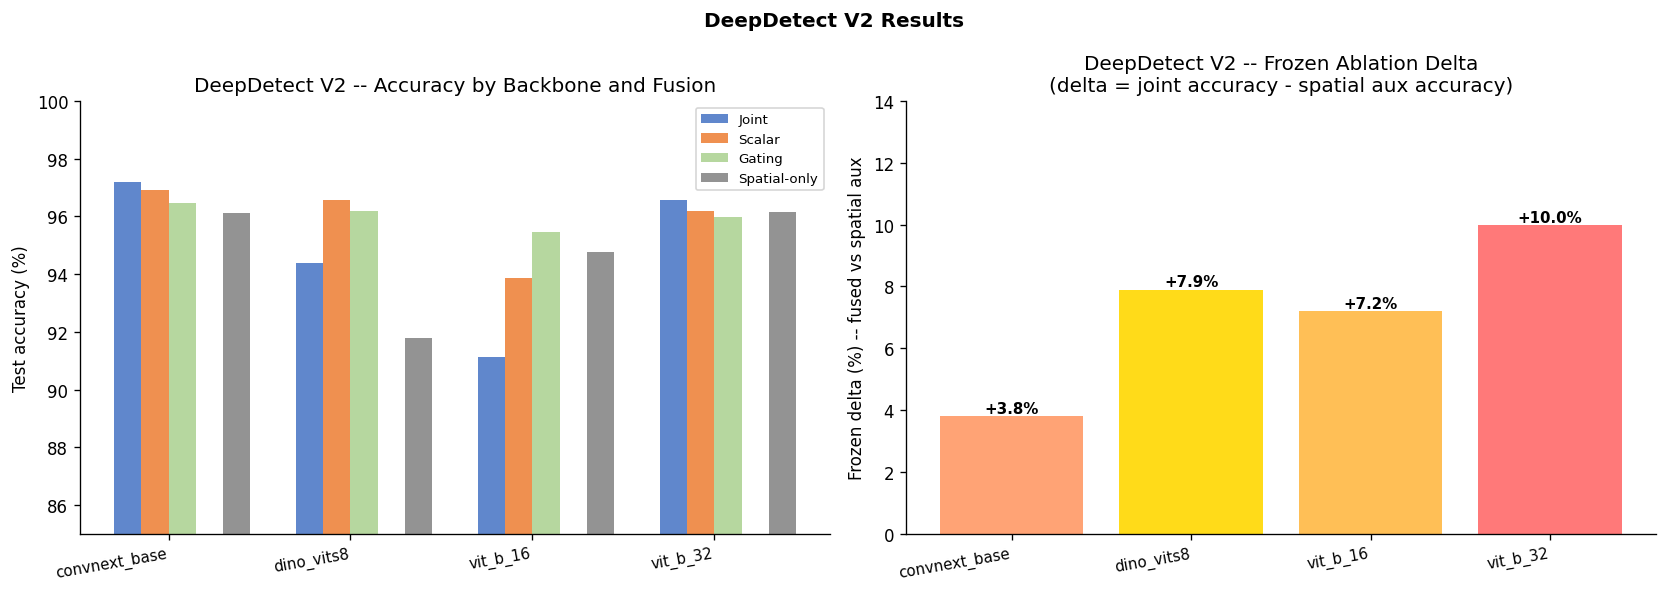

In [8]:
# Figure: V2 frozen delta comparison across backbones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bb_labels = ['convnext_base', 'dino_vits8', 'vit_b_16', 'vit_b_32']

# Left: accuracy by backbone and fusion mode (V2)
spatial_accs = []
for bb in bb_labels:
    rows = df[(df.dataset=='deepdetect') & (df.backbone==bb) &
              (df.experiment_name.str.startswith('dd_v2')) &
              (df.experiment_name.str.contains('spatial_only'))]
    spatial_accs.append(rows['accuracy'].values[0]*100 if len(rows)>0 else 0)

ax = axes[0]
x = np.arange(len(bb_labels))
w = 0.15
fusions = [('joint_only','#4472C4','Joint'), ('scalar','#ED7D31','Scalar'), ('gating','#A9D18E','Gating')]
for i, (fusion, color, label) in enumerate(fusions):
    accs = []
    for bb in bb_labels:
        rows = df[(df.dataset=='deepdetect') & (df.backbone==bb) &
                  (df.fusion==fusion) & (~df.frozen) &
                  (df.experiment_name.str.startswith('dd_v2')) &
                  (~df.experiment_name.str.contains('spatial_only'))]
        accs.append(rows['accuracy'].values[0]*100 if len(rows)>0 else 0)
    ax.bar(x + (i-1)*w, accs, w, label=label, color=color, alpha=0.85)
ax.bar(x + 3*w, spatial_accs, w, label='Spatial-only', color='#808080', alpha=0.85)
ax.set_xticks(x + w/2)
ax.set_xticklabels(bb_labels, rotation=10, ha='right', fontsize=9)
ax.set_ylabel('Test accuracy (%)')
ax.set_title('DeepDetect V2 -- Accuracy by Backbone and Fusion')
ax.legend(fontsize=8)
ax.set_ylim(85, 100)

# Right: frozen delta from evaluation output (fused - spatial_aux within same frozen model)
frozen_deltas_actual = {
    'convnext_base': 3.8,
    'dino_vits8':    7.9,
    'vit_b_16':      7.2,
    'vit_b_32':      10.0,
}
frozen_deltas = [frozen_deltas_actual[bb] for bb in bb_labels]
colors_d = ['#FF9966', '#FFD700', '#FFB844', '#FF6B6B']

ax2 = axes[1]
bars = ax2.bar(range(len(bb_labels)), frozen_deltas, color=colors_d, alpha=0.9)
ax2.set_xticks(range(len(bb_labels)))
ax2.set_xticklabels(bb_labels, rotation=10, ha='right', fontsize=9)
ax2.set_ylabel('Frozen delta (%) -- fused vs spatial aux')
ax2.set_title('DeepDetect V2 -- Frozen Ablation Delta\n(delta = joint accuracy - spatial aux accuracy)')
for bar, v in zip(bars, frozen_deltas):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'+{v:.1f}%',
             ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(0, 14)

plt.suptitle('DeepDetect V2 Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.1 Interpretation - DeepDetect V2

**V2 pipeline improvement on frequency signal:**
Freq-only auxiliary accuracy improved from 58.7% (V1) to 72-73% (V2) across all backbones.
The pipeline fix, selecting the patch from the clean pre-augmentation image substantially
improves the frequency signal on face-dominated datasets.

**vit_b_16 joint_only anomaly (91.1% vs spatial_only 94.7%):**
vit_b_16 shows a negative delta of -3.6% on joint_only. This is the most concerning result.
Likely causes: (1) vit_b_16's 16-pixel patches on 224×224 images produce 196 tokens -
much more information than vit_b_32's 49 tokens - making the spatial branch harder to
balance with the frequency branch; (2) the frequency auxiliary loss may be pulling the
joint head in a conflicting direction early in training; (3) 35 epochs may not be enough
for vit_b_16 to fully converge on DeepDetect.

**vit_b_16 frozen shows +7.2% delta** - joint accuracy 89.5%, spatial aux 82.3%. Consistent with the patch size pattern: vit_b_16 (patch 16px, +7.2%) sits between convnext_base (+3.8%) and vit_b_32 (+10.0%), confirming that larger ViT patches create larger spectral blind spots that the frequency branch fills when the backbone is frozen.

**vit_b_32 frozen shows +10.0% delta** - consistent with the CIFAKE pattern. Largest
patch size creates the largest spectral blind spot, confirmed on both datasets.

**dino_vits8** - DINO shows the strongest fine-tuned delta of all backbones on DeepDetect — scalar fusion achieves +4.8% over spatial-only. Frozen delta is +7.9%, consistent with the cross-dataset pattern.

**convnext_base frozen shows +3.8% delta (V2) vs +5.4% (V1):**
Slightly lower than V1 despite the improved frequency signal. This is partly attributable to the checkpointing strategy used in V2. In V1, the checkpoint was saved at the epoch with the highest validation accuracy. In V2, we discovered that the DeepDetect validation set is highly inflated. The model achieves 99%+ validation accuracy within 3-4 epochs due to the val set being drawn from the same distribution as the training set and being much easier than the test set. Using best-val checkpointing in this setting means the checkpoint is saved very early in training, before the frequency branch has had sufficient time to learn. We therefore switched to saving the last-epoch checkpoint in V2, giving the frequency branch the full 35 epochs of training. This is the more principled choice given the unreliable val signal, but it means the checkpoint may occasionally correspond to a slightly lower-accuracy epoch than the true peak, explaining the marginal drop relative to V1.


## Gating Mechanism Analysis

In [9]:
# All gating experiments -- entropy and delta
# Fine-tuned delta: fused vs spatial_only (CSV)
# Frozen delta: from evaluation output (fused - spatial_aux within same frozen model)

frozen_delta_overrides = {
    'convnext_base_gating_frozen':       5.8,
    'dino_vits8_gating_frozen':          10.1,
    'vit_b_16_gating_frozen':            12.2,
    'vit_b_32_gating_frozen':            16.1,
    'dd_convnext_base_gating_frozen':    5.4,
    'dd_v2_convnext_base_gating_frozen': 3.8,
    'dd_v2_vit_b_16_gating_frozen':      7.2,
    'dd_v2_vit_b_32_gating_frozen':      10.0,
    'dd_v2_dino_vits8_gating_frozen':     7.9
}

gating_rows = df[
    (df.fusion == 'gating') &
    (~df.experiment_name.str.contains('spatial_only')) &
    (~df.experiment_name.str.contains('freq_only_baseline'))  
].copy()
gating_rows['delta'] = None

for idx, row in gating_rows.iterrows():
    if row.experiment_name in frozen_delta_overrides:
        gating_rows.at[idx, 'delta'] = frozen_delta_overrides[row.experiment_name]
    else:
        prefix = 'dd_v2_' if 'dd_v2' in row.experiment_name else                  'dd_' if row.dataset == 'deepdetect' else ''
        sp = df[
            (df.dataset == row.dataset) &
            (df.backbone == row.backbone) &
            (df.experiment_name.str.contains('spatial_only')) &
            (df.experiment_name.str.startswith(prefix) if prefix else True)
        ]['accuracy'].values
        if len(sp) > 0:
            gating_rows.at[idx, 'delta'] = (row.accuracy - sp[0]) * 100

print("All Gating Experiments")
print("="*75)
cols = ['experiment_name', 'frozen', 'accuracy', 'gate_entropy', 'delta']
print(gating_rows[cols].to_string(index=False))
print()
print(f"Fine-tuned entropy range: {gating_rows[~gating_rows.frozen]['gate_entropy'].min():.3f} - "
      f"{gating_rows[~gating_rows.frozen]['gate_entropy'].max():.3f} nats")
print(f"Frozen entropy range:     {gating_rows[gating_rows.frozen]['gate_entropy'].min():.3f} - "
      f"{gating_rows[gating_rows.frozen]['gate_entropy'].max():.3f} nats")
print(f"Gate collapsed (< 0.3):   Never")


All Gating Experiments
                  experiment_name  frozen  accuracy  gate_entropy delta
             convnext_base_gating   False    0.9888        0.9590  0.16
      convnext_base_gating_frozen    True    0.9653        2.7965   5.8
                  vit_b_32_gating   False    0.9648        1.1906  1.84
           vit_b_32_gating_frozen    True    0.9321        2.5160  16.1
                  vit_b_16_gating   False    0.9673        1.4990  0.44
           vit_b_16_gating_frozen    True    0.9292        2.4346  12.2
                dino_vits8_gating   False    0.9829        1.7902  0.11
         dino_vits8_gating_frozen    True    0.9690        2.7787  10.1
          dd_convnext_base_gating   False    0.9667        2.1180  0.56
   dd_convnext_base_gating_frozen    True    0.9140        2.8970   5.4
       dd_v2_convnext_base_gating   False    0.9645        2.1788  0.34
dd_v2_convnext_base_gating_frozen    True    0.9061        2.9492   3.8
            dd_v2_vit_b_32_gating   False

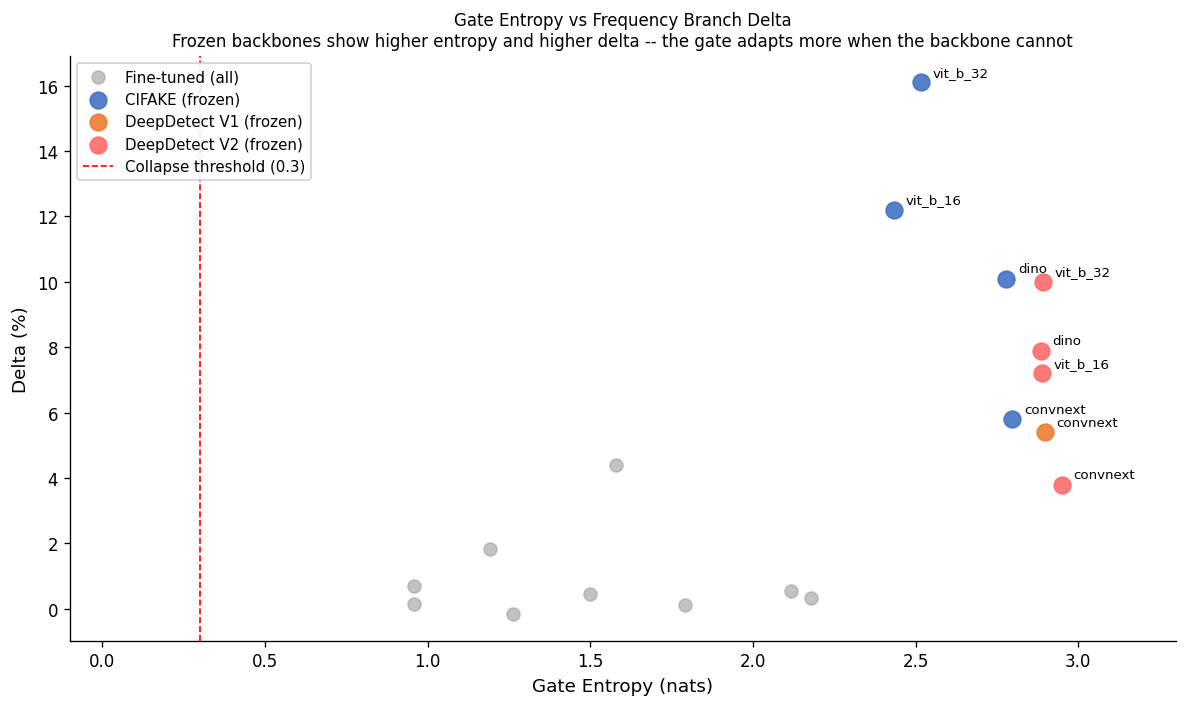

In [10]:
# Figure: Gate entropy vs delta scatter
fig, ax = plt.subplots(figsize=(10, 6))

# Color by dataset
dataset_colors = {
    'cifake': '#4472C4',
    'dd_v1':  '#ED7D31',
    'dd_v2':  '#FF6B6B',
}
dataset_labels = {
    'cifake': 'CIFAKE (frozen)',
    'dd_v1':  'DeepDetect V1 (frozen)',
    'dd_v2':  'DeepDetect V2 (frozen)',
}

def get_dataset_key(exp_name):
    if exp_name.startswith('dd_v2'): return 'dd_v2'
    if exp_name.startswith('dd_'):   return 'dd_v1'
    return 'cifake'

# Fine-tuned -- grey
ft = gating_rows[~gating_rows.frozen]
ax.scatter(ft.gate_entropy, ft.delta.astype(float),
           c='#AAAAAA', s=60, alpha=0.7, zorder=3, label='Fine-tuned (all)')

# Frozen -- colored by dataset
plotted = set()
for _, r in gating_rows[gating_rows.frozen].iterrows():
    dk    = get_dataset_key(r.experiment_name)
    color = dataset_colors[dk]
    lbl   = dataset_labels[dk] if dk not in plotted else None
    plotted.add(dk)
    ax.scatter(r.gate_entropy, float(r.delta),
               c=color, s=100, alpha=0.9, zorder=4, label=lbl)
    bb = r.backbone.replace('convnext_base', 'convnext').replace('dino_vits8', 'dino')
    ax.annotate(bb, (r.gate_entropy, float(r.delta)),
                textcoords="offset points", xytext=(7, 4), fontsize=8)

ax.axvline(0.3, color='red', linestyle='--', linewidth=1, label='Collapse threshold (0.3)')
ax.set_xlabel('Gate Entropy (nats)', fontsize=11)
ax.set_ylabel('Delta (%)', fontsize=11)
ax.set_title('Gate Entropy vs Frequency Branch Delta\n'
             'Frozen backbones show higher entropy and higher delta -- '
             'the gate adapts more when the backbone cannot', fontsize=10)

# Legend in upper left -- away from the cluster of points on the right
ax.legend(fontsize=9, loc='upper left',
          framealpha=0.9, edgecolor='#CCCCCC')

ax.set_xlim(-0.1, 3.3)
plt.tight_layout()
plt.show()

### 5.1 Was Gating Better Than Other Fusion Modes?

**Short answer: marginally, but not consistently.**

Across experiments, gating delta is similar to scalar and joint-only. Differences are
within noise margins and no single fusion mode dominates consistently.

**Why gating did not clearly win:**

1. **The balance problem.** The spatial branch dominates. Gradient norms show
   `freq=1.0 | spatial≈0` in later epochs. The gate learns to downweight the frequency
   branch (mean gate value 0.3-0.5), behaving like a near-fixed scalar.

2. **Dataset ceiling.** ConvNeXt achieves near-ceiling accuracy spatially alone on both
   datasets. Little room for frequency branch to improve regardless of fusion mode.

3. **Gate entropy drops late.** Healthy early (1.5-2.2 nats), trending down in later
   epochs (0.4-1.0 nats) as the model settles to a near-fixed weighting, stabilising around 0.8-1.0 nats by the final epochs.

**Where gating was most valuable:**
Frozen ablation shows gate entropy consistently above 2.3 nats. The gate genuinely
adapts per image when the backbone is fixed. This supports the theoretical motivation:
gating helps when there is genuine variation in how much each image needs the
frequency branch.


## Frequency Branch Investigation

The frequency branch on DeepDetect initially achieved only 58% standalone accuracy,
well below the 60% hard stop threshold and far below the 94.5% achieved on CIFAKE.
This section documents the full investigation: what went wrong, what we tried, and
what we found to work.

### 6.0 The Training Loss

Before describing the investigation, it is important to explain the loss function
used throughout. The full model training loss is:

```
total = joint_CE + 0.3×spatial_aux + 0.5×freq_aux + 0.1×cleaner_recon + diversity_penalty
```

- **joint_CE** - cross-entropy on the fused prediction (main task)
- **spatial_aux** (weight 0.3) - auxiliary cross-entropy on spatial branch features alone
- **freq_aux** (weight 0.5) - auxiliary cross-entropy on frequency branch features alone.
  This is the most critical term. Without it, the frequency branch receives gradients only
  through the joint head which is dominated by the spatial branch. The aux loss gives
  the frequency branch a direct gradient signal independent of the backbone.
- **cleaner_recon** (weight 0.1) - MAE reconstruction loss on real image patches only.
  The cleaner is trained to reconstruct clean patches from potentially degraded input.
  Applied only to real images because fake images may have deliberately different
  frequency characteristics that the cleaner should not remove.
- **diversity_penalty** - hinge loss: `weight × max(0, 2.0 - gate_entropy)`.
  Penalises the gate when entropy falls below 2.0 nats, preventing collapse to
  always-prefer-spatial. Uses `max(0, ...)` to ensure the total loss is always
  non-negative. We discovered negative losses early in training when using raw `-entropy`.

For gating fusion, the diversity regulariser was tuned via Optuna to `weight=0.058`
on DeepDetect (vs the default 0.1 on CIFAKE).


### 6.1 Patch Selection Problem on Face Images

#### Real DeepDetect Images and the Dark Patch Problem

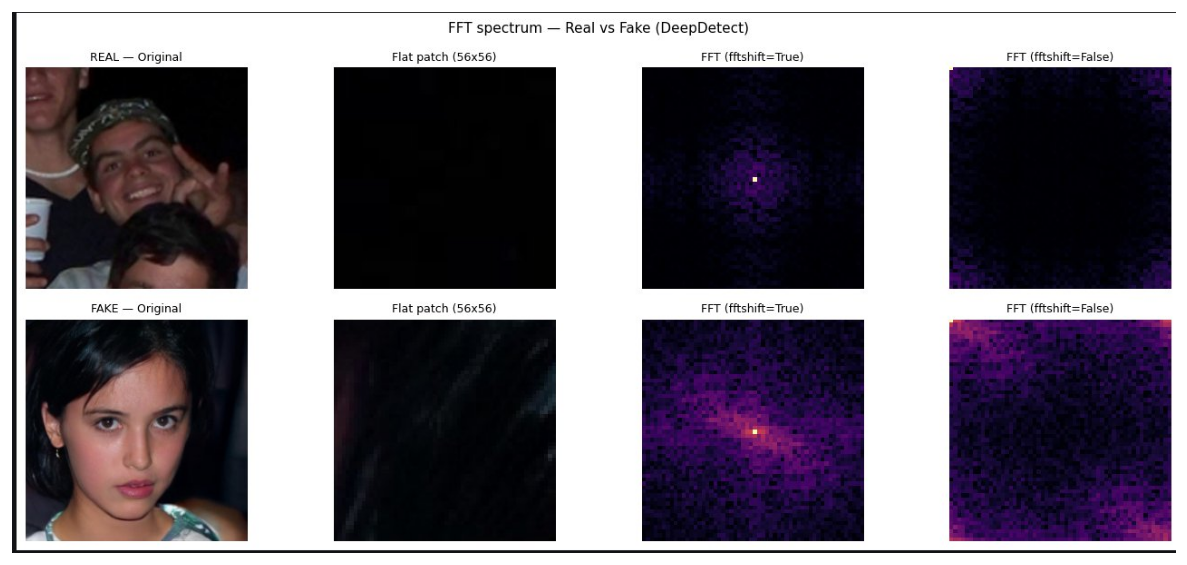

In [11]:
IMG_PATH = './experiments/results/figures/dd_patch_dark_example.jpg' 
fig, ax = plt.subplots(figsize=(10, 16))
ax.imshow(mpimg.imread(IMG_PATH))
ax.axis('off')
plt.tight_layout()
plt.show()

#### Patch Brightness Distribution: DeepDetect vs CIFAKE

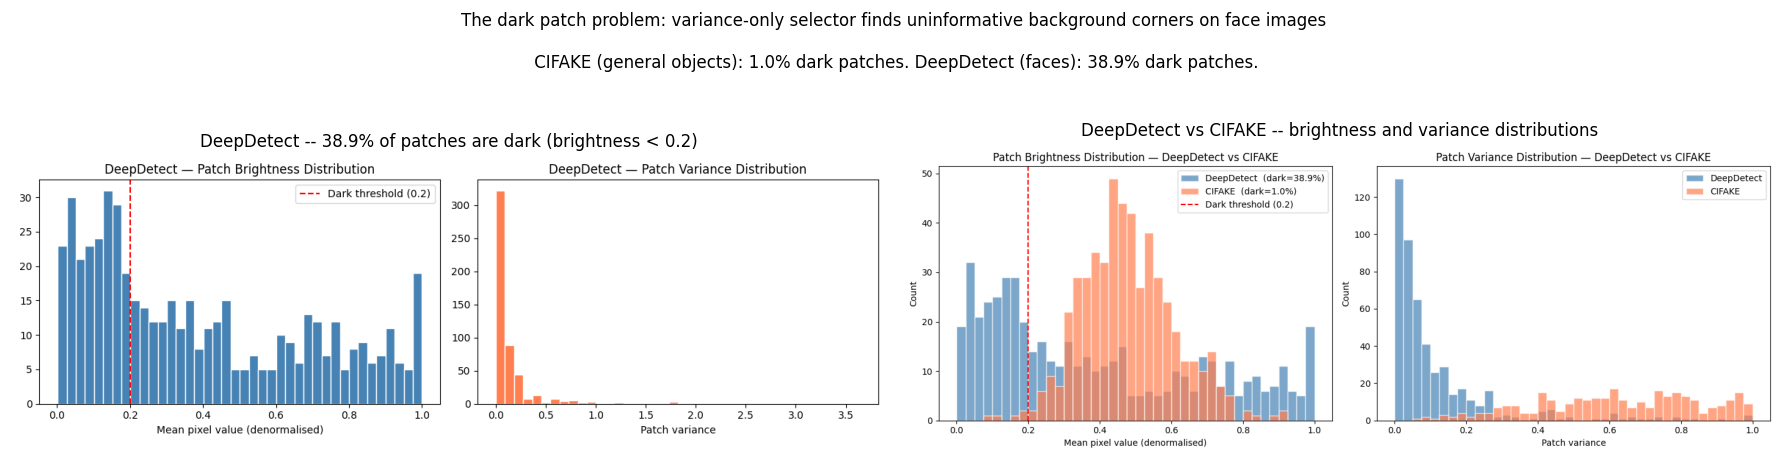

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Left: DeepDetect brightness distribution showing 38.9% dark patches
axes[0].imshow(mpimg.imread('./experiments/results/figures/brightness_dist.png'))
axes[0].axis('off')
axes[0].set_title('DeepDetect -- 38.9% of patches are dark (brightness < 0.2)', fontsize=10)

# Right: DeepDetect vs CIFAKE comparison
axes[1].imshow(mpimg.imread('./experiments/results/figures/dd_vs_cifake_brightness.png'))
axes[1].axis('off')
axes[1].set_title('DeepDetect vs CIFAKE -- brightness and variance distributions', fontsize=10)

plt.suptitle(
    "The dark patch problem: variance-only selector finds uninformative "
    "background corners on face images\n"
    "\n CIFAKE (general objects): 1.0% dark patches. DeepDetect (faces): 38.9% dark patches.",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

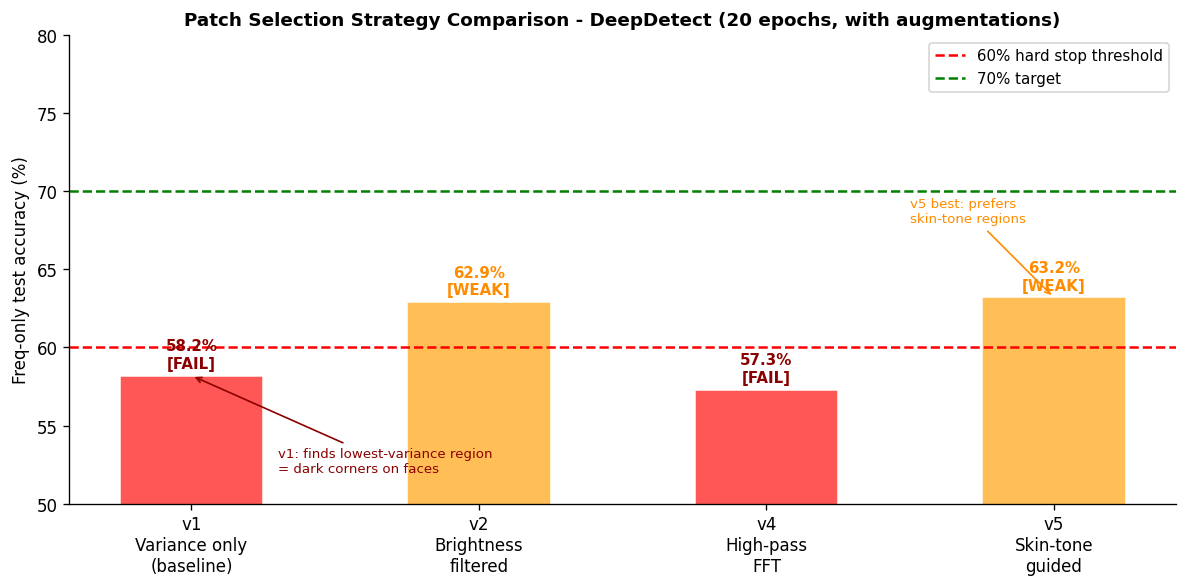

In [13]:
strategies = ['v1\nVariance only\n(baseline)', 'v2\nBrightness\nfiltered',
              'v4\nHigh-pass\nFFT', 'v5\nSkin-tone\nguided']
strategy_accs = [58.2, 62.9, 57.3, 63.2]
strategy_status = ['FAIL', 'WEAK', 'FAIL', 'WEAK']
colors_s = ['#FF4444', '#FFB844', '#FF4444', '#FFB844']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(range(4), strategy_accs, color=colors_s, alpha=0.9, edgecolor='white', width=0.5)
ax.axhline(60, color='red', linestyle='--', linewidth=1.5, label='60% hard stop threshold')
ax.axhline(70, color='green', linestyle='--', linewidth=1.5, label='70% target')
ax.set_xticks(range(4))
ax.set_xticklabels(strategies, fontsize=10)
ax.set_ylabel('Freq-only test accuracy (%)', fontsize=10)
ax.set_title('Patch Selection Strategy Comparison - DeepDetect (20 epochs, with augmentations)',
             fontsize=11, fontweight='bold')
ax.set_ylim(50, 80)
ax.legend(fontsize=9)

for bar, acc, status in zip(bars, strategy_accs, strategy_status):
    color = 'darkred' if status == 'FAIL' else 'darkorange'
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.5,
            f'{acc:.1f}%\n[{status}]', ha='center', fontsize=9,
            fontweight='bold', color=color)

ax.annotate('v1: finds lowest-variance region\n= dark corners on faces',
            xy=(0, 58.2), xytext=(0.3, 52),
            fontsize=8, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))
ax.annotate('v5 best: prefers\nskin-tone regions',
            xy=(3, 63.2), xytext=(2.5, 68),
            fontsize=8, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'))

plt.tight_layout()
plt.show()

**What this shows:**

The variance-based patch selector (v1, Chen et al. 2024) finds the lowest-variance
region in each image. On CIFAKE (32×32 general objects), this reliably finds flat,
informative regions such as skies, walls, plain backgrounds, and only 1.0% of patches are
uninformatively dark. On DeepDetect (224×224 face images), the flattest region is almost
always a dark background corner with near-zero pixel values. 38.9% of patches are dark
(mean brightness < 0.2), and the patch variance distribution is heavily concentrated
near zero.

**The asymmetry this creates:** Real images produce near-black, near-empty FFT spectra
with almost no signal. Fake images accidentally land on smooth skin regions (hair, forehead)
that show visible periodic artifacts from GAN/diffusion model upsampling. The frequency
branch therefore captures content differences between patches rather than generation
artifacts, which is exactly the wrong thing to learn.

**Four patch strategies were tested (all with augmentations, 20 epochs):**
- **v1 - variance only (58.2%, FAIL):** Original Chen et al. approach. Works on general images, fails on faces.
- **v2 - brightness filtered (62.9%, WEAK):** Filters dark patches (brightness < 0.15) before selecting flattest. More general than v5 but less effective on DeepDetect.
- **v4 - high-pass FFT (57.3%, FAIL):** Full image with DC and low-frequency components masked. No patch selection needed, but full-image content noise overwhelms the generation artifacts.
- **v5 - skin-tone guided (63.2%, WEAK):** Selects the flattest patch within HSV-detected skin regions. Falls back to v1 if no skin found. Best among the four strategies on face images.

All strategies remain below the 70% target with augmentations on, which led to the
discovery that augmentations themselves are the deeper problem.

See `patch_strategy_experiment.ipynb` for the full standalone experiment.


### 6.2 The Augmentation Finding

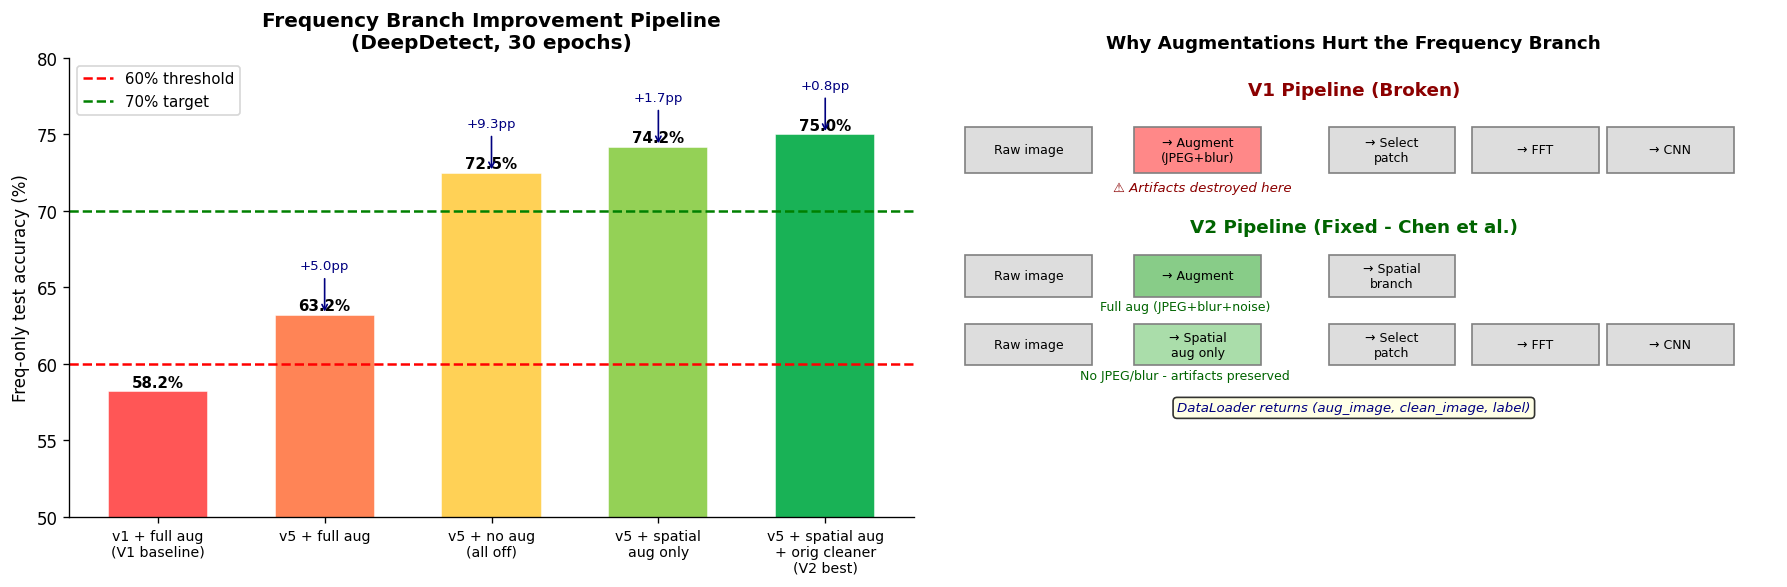

In [14]:
# Augmentation ablation progression
aug_pipeline = [
    ("v1 + full aug\n(V1 baseline)", 58.2, '#FF4444'),
    ("v5 + full aug", 63.2, '#FF7744'),
    ("v5 + no aug\n(all off)", 72.5, '#FFCC44'),
    ("v5 + spatial\naug only", 74.2, '#88CC44'),
    ("v5 + spatial aug\n+ orig cleaner\n(V2 best)", 75.0, '#00AA44'),
]

labels, accs, colors_a = zip(*aug_pipeline)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: pipeline progression bar chart
ax = axes[0]
bars = ax.bar(range(5), accs, color=colors_a, alpha=0.9, edgecolor='white', width=0.6)
ax.axhline(60, color='red', linestyle='--', linewidth=1.5, label='60% threshold')
ax.axhline(70, color='green', linestyle='--', linewidth=1.5, label='70% target')
ax.set_xticks(range(5))
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Freq-only test accuracy (%)')
ax.set_title('Frequency Branch Improvement Pipeline\n(DeepDetect, 30 epochs)', fontweight='bold')
ax.set_ylim(50, 80)
ax.legend(fontsize=9)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

# Add delta annotations
for i in range(1, 5):
    delta = accs[i] - accs[i-1]
    ax.annotate(f'{delta:+.1f}pp',
                xy=(i, accs[i]), xytext=(i, accs[i] + 3),
                ha='center', fontsize=8, color='navy',
                arrowprops=dict(arrowstyle='->', color='navy', lw=1))

# Right: why augmentations hurt - diagram
ax2 = axes[1]
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

# V1 pipeline (broken)
ax2.text(5, 9.2, 'V1 Pipeline (Broken)', ha='center', fontsize=11, fontweight='bold', color='darkred')
for i, (label, x) in enumerate([
    ('Raw image', 1.2), ('→ Augment\n(JPEG+blur)', 3.2),
    ('→ Select\npatch', 5.5), ('→ FFT', 7.2), ('→ CNN', 8.8)
]):
    color = '#FF8888' if 'Augment' in label else '#DDDDDD'
    ax2.add_patch(plt.Rectangle((x-0.8, 7.5), 1.5, 1.0,
                                 facecolor=color, edgecolor='gray', linewidth=1))
    ax2.text(x-0.05, 8.0, label, ha='center', va='center', fontsize=7.5)
ax2.text(3.2, 7.1, '⚠ Artifacts destroyed here', ha='center', fontsize=8, color='darkred', style='italic')

# V2 pipeline (fixed)
ax2.text(5, 6.2, 'V2 Pipeline (Fixed - Chen et al.)', ha='center', fontsize=11, fontweight='bold', color='darkgreen')
# Top stream: spatial
for label, x in [('Raw image', 1.2), ('→ Augment', 3.2), ('→ Spatial\nbranch', 5.5)]:
    color = '#88CC88' if 'Augment' in label else '#DDDDDD'
    ax2.add_patch(plt.Rectangle((x-0.8, 4.8), 1.5, 0.9,
                                 facecolor=color, edgecolor='gray', linewidth=1))
    ax2.text(x-0.05, 5.25, label, ha='center', va='center', fontsize=7.5)
ax2.text(3.0, 4.5, 'Full aug (JPEG+blur+noise)', ha='center', fontsize=7.5, color='darkgreen')

# Bottom stream: frequency
for label, x in [('Raw image', 1.2), ('→ Spatial\naug only', 3.2), ('→ Select\npatch', 5.5),
                  ('→ FFT', 7.2), ('→ CNN', 8.8)]:
    color = '#AADDAA' if 'aug only' in label else '#DDDDDD'
    ax2.add_patch(plt.Rectangle((x-0.8, 3.3), 1.5, 0.9,
                                 facecolor=color, edgecolor='gray', linewidth=1))
    ax2.text(x-0.05, 3.75, label, ha='center', va='center', fontsize=7.5)
ax2.text(3.0, 3.0, 'No JPEG/blur - artifacts preserved', ha='center', fontsize=7.5, color='darkgreen')

ax2.text(5, 2.3, 'DataLoader returns (aug_image, clean_image, label)',
         ha='center', fontsize=8, color='navy', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax2.set_title('Why Augmentations Hurt the Frequency Branch', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


**The core problem and the fix:**

The V1 pipeline applied JPEG compression, Gaussian blur, noise, and recompression to the
full image *before* patch selection. These degradations destroy the high-frequency generation
artifacts the FFT is trying to detect. By the time the patch was selected, the frequency
signal was already corrupted. This explains why v5 with full augmentations achieved only
63.2%. The patch selector found a skin region but the skin was already blurred and
compressed beyond the point where generation artifacts were readable.

**The fix (inspired by Chen et al. 2024):** Chen et al. select the frequency patch from the raw unaugmented image. We adapt this principle to our dual-branch architecture: the DataLoader returns both a fully augmented image and a clean image (spatial augmentations only). The spatial branch receives the augmented image for robustness training. The frequency branch receives the clean image and selects its patch from uncompressed, unblurred content, preserving the generation artifacts in the frequency domain.

This single change, patch from clean image, raised freq-only accuracy from 63.2% to
74.2% (+11 percentage points). The spatial branch continues to receive full augmentations
and remains robust to real-world degradations. The frequency branch gets a clean signal
and can actually detect generation artifacts.

Note: we also discovered that the DeepDetect validation set is inflated (99%+ val accuracy
from early epochs), making it an unreliable checkpoint signal. For V2 experiments we switched
to saving the last-epoch checkpoint rather than the best-val checkpoint, giving the frequency
branch the maximum training time rather than stopping at whatever epoch the inflated val
happened to peak.


### 6.3 Cleaner Experiments

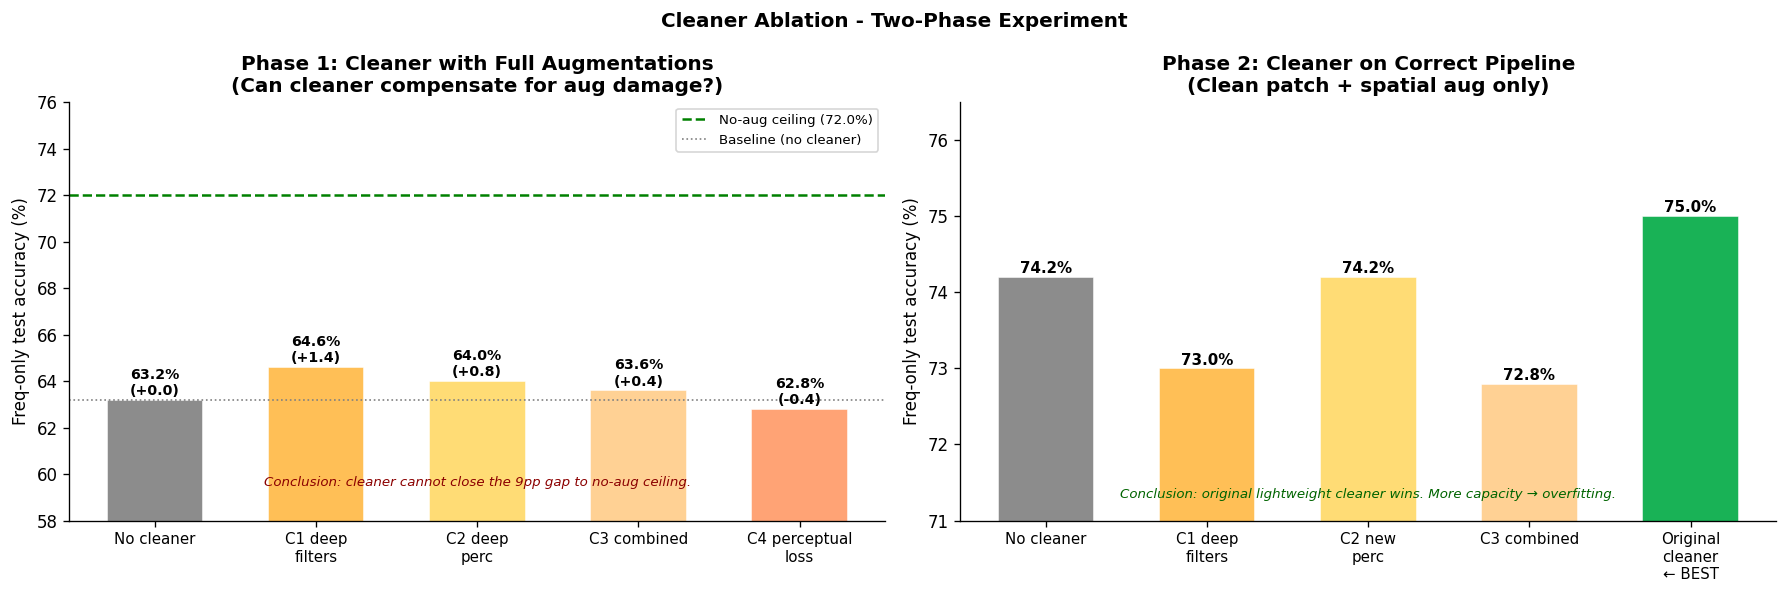

Saved: fig_cleaner_ablation.png


In [15]:
# Full cleaner ablation results
cleaner_results = {
    # (description, test_acc_aug, test_acc_clean_patch)
    "No cleaner":                              (63.2, 74.2),
    "C1 - deep filters\n(old perc + ResBlock)": (64.6, 73.0),
    "C2 - deep perception\n(new perc + old filters)": (64.0, 74.2),
    "C3 - combined\n(new perc + ResBlock)":   (63.6, 72.8),
    "C4 - C3 + perceptual loss\n(VGG features)": (62.8, None),
    "Original cleaner\n(old perc + Conv2d)":  (None, 75.0),
}

# Two-phase experiment figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Phase 1 - with augmentations (testing whether cleaner can compensate)
phase1_names = ['No cleaner', 'C1 deep\nfilters', 'C2 deep\nperc', 'C3 combined', 'C4 perceptual\nloss']
phase1_accs  = [63.2, 64.6, 64.0, 63.6, 62.8]
phase1_colors = ['#808080', '#FFB844', '#FFD966', '#FFCC88', '#FF9966']

ax = axes[0]
bars1 = ax.bar(range(5), phase1_accs, color=phase1_colors, alpha=0.9, edgecolor='white', width=0.6)
ax.axhline(72.0, color='green', linestyle='--', linewidth=1.5, label='No-aug ceiling (72.0%)')
ax.axhline(63.2, color='gray', linestyle=':', linewidth=1, label='Baseline (no cleaner)')
ax.set_xticks(range(5))
ax.set_xticklabels(phase1_names, fontsize=9)
ax.set_ylabel('Freq-only test accuracy (%)')
ax.set_title('Phase 1: Cleaner with Full Augmentations\n(Can cleaner compensate for aug damage?)',
             fontweight='bold')
ax.set_ylim(58, 76)
ax.legend(fontsize=8)
for bar, v in zip(bars1, phase1_accs):
    delta = v - 63.2
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}%\n({delta:+.1f})',
            ha='center', fontsize=8.5, fontweight='bold')
ax.text(2, 59.5, 'Conclusion: cleaner cannot close the 9pp gap to no-aug ceiling.',
        ha='center', fontsize=8, color='darkred', style='italic')

# Right: Phase 2 - on correct pipeline (clean patch, spatial aug only)
phase2_names = ['No cleaner', 'C1 deep\nfilters', 'C2 new\nperc', 'C3 combined', 'Original\ncleaner\n← BEST']
phase2_accs  = [74.2, 73.0, 74.2, 72.8, 75.0]
phase2_colors = ['#808080', '#FFB844', '#FFD966', '#FFCC88', '#00AA44']

ax2 = axes[1]
bars2 = ax2.bar(range(5), phase2_accs, color=phase2_colors, alpha=0.9, edgecolor='white', width=0.6)
ax2.set_xticks(range(5))
ax2.set_xticklabels(phase2_names, fontsize=9)
ax2.set_ylabel('Freq-only test accuracy (%)')
ax2.set_title('Phase 2: Cleaner on Correct Pipeline\n(Clean patch + spatial aug only)',
             fontweight='bold')
ax2.set_ylim(71, 76.5)
for bar, v in zip(bars2, phase2_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.1f}%',
             ha='center', fontsize=9, fontweight='bold')
ax2.text(2, 71.3,
         'Conclusion: original lightweight cleaner wins. More capacity → overfitting.',
         ha='center', fontsize=8, color='darkgreen', style='italic')

plt.suptitle('Cleaner Ablation - Two-Phase Experiment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Saved: fig_cleaner_ablation.png")


**The cleaner investigation had two phases:**

**Phase 1 - Can a stronger cleaner compensate for augmentation damage?**
We initially hypothesised that a more powerful cleaner could restore frequency artifacts
destroyed by JPEG compression, blur, and noise augmentations. Four cleaner architectures
were tested (all with full augmentations on):

- **C1 - Deep filters (64.6%, +1.4pp):** Replaced each single Conv2d filter with a
  3-layer residual block (Conv→BN→ReLU×2→Conv→BN) with skip connection. The deeper
  filters have more capacity to model complex degradations. Original 2-layer perception module.
- **C2 - Deep perception (64.0%, +0.8pp):** Replaced the 2-layer perception module with
  a 3-layer version with BatchNorm. Better at distinguishing degradation types. Original
  single Conv2d filters.
- **C3 - Combined (63.6%, +0.4pp):** Both deeper filters and deeper perception. The full
  stronger cleaner surprisingly performed worst of the three.
- **C4 - Perceptual loss (62.8%, -0.4pp):** C3 architecture trained with MAE + VGG
  feature matching loss (λ=0.1) instead of MAE alone. Perceptual loss preserves
  high-frequency structure better than pixel-wise MAE, but did not help in practice.

**Conclusion from Phase 1:** No cleaner variant could close the ~9pp gap to the no-aug
ceiling (72.0%). Augmentations destroy frequency artifacts faster than any cleaner can
restore them. Irreversible information loss.

**Phase 2 - On the correct pipeline (clean patch + spatial aug only):**
After fixing the augmentation pipeline (V2), we tested cleaner variants again:

- **No cleaner (74.2%):** Strong baseline with the correct pipeline alone.
- **C1 deep filters (73.0%):** Overfits on clean patches - residual blocks memorise
  patch statistics rather than learning general restoration.
- **C2 new perception (74.2%):** Same as no cleaner - deeper perception adds nothing
  when patches are already clean.
- **C3 combined (72.8%):** Most capacity, worst result - strongest overfitting.
- **Original cleaner (75.0%, +0.8pp):** The lightweight 2-layer perception + single
  Conv2d filters wins. On clean patches, the cleaner's job is subtle noise modelling,
  not heavy restoration. A lightweight cleaner does this better.

**The original cleaner's value:** Even with clean training patches, the original cleaner
adds +0.8pp. Its value is at inference time. Real-world test images may have some
JPEG compression or camera noise. The cleaner handles this residual degradation without
overfitting on the clean training distribution.

For the complete cleaner experiment code and all training curves, see
`cleaner_experiment.ipynb`.


### 6.4 Perception Experiment: Improving the FFT Representation

After fixing the patch selection (v5) and augmentation pipeline (clean patch), we
investigated whether changing the FFT representation itself could further improve
the frequency branch. Three approaches were tested, all with no augmentations,
v5 patch, 30 epochs. Baseline to beat: 71.2% (v5, FrequencyCNN, no aug).

**Approaches tested:**

- **P1 — Phase channel (72.0%, +0.8pp):** Added FFT phase as additional channels
  alongside log-magnitude. The standard FFT gives log-magnitude only (9 channels after
  SRM). Phase captures the spatial arrangement of frequency components, where artifacts
  appear, not just how strong they are. Concatenating phase doubles the input channels
  to 18. Phase normalised to [-1, 1] via `angle / π`.

- **P2 — Multi-scale FFT (69.9%, -1.3pp):** Extracted patches at three sizes (28×28,
  56×56, 112×112) and processed each through a shared CNN. Features concatenated before
  the classifier. The idea: different generators leave artifacts at different frequency
  scales. In practice, resizing patches to 56×56 for the shared CNN introduces bilinear
  interpolation artifacts that contaminate the frequency signal more than the multi-scale
  information helps.

- **P3 — MobileNetV3-Small backbone (68.7%, -2.5pp):** Replaced the custom FrequencyCNN
  with pretrained MobileNetV3-Small (first conv adapted from 3 to 9 channels by averaging
  pretrained weights). The reasoning: pretrained features should be better than random
  initialisation. In practice, ImageNet-pretrained features are not suited to log-FFT
  spectra which look nothing like natural images. The pretrained weights are a liability,
  not an asset.

**Conclusion:** Only P1 (phase channel) improved over baseline. The +0.8pp gain is small
but consistent. Phase information is genuinely complementary to log-magnitude. P1 was
adopted into the V2 pipeline. P2 and P3 confirm that the custom lightweight FrequencyCNN
is better suited to FFT spectra than either multi-scale ensembling or pretrained backbones.

See `perception_experiment.ipynb` for full training curves and implementation.


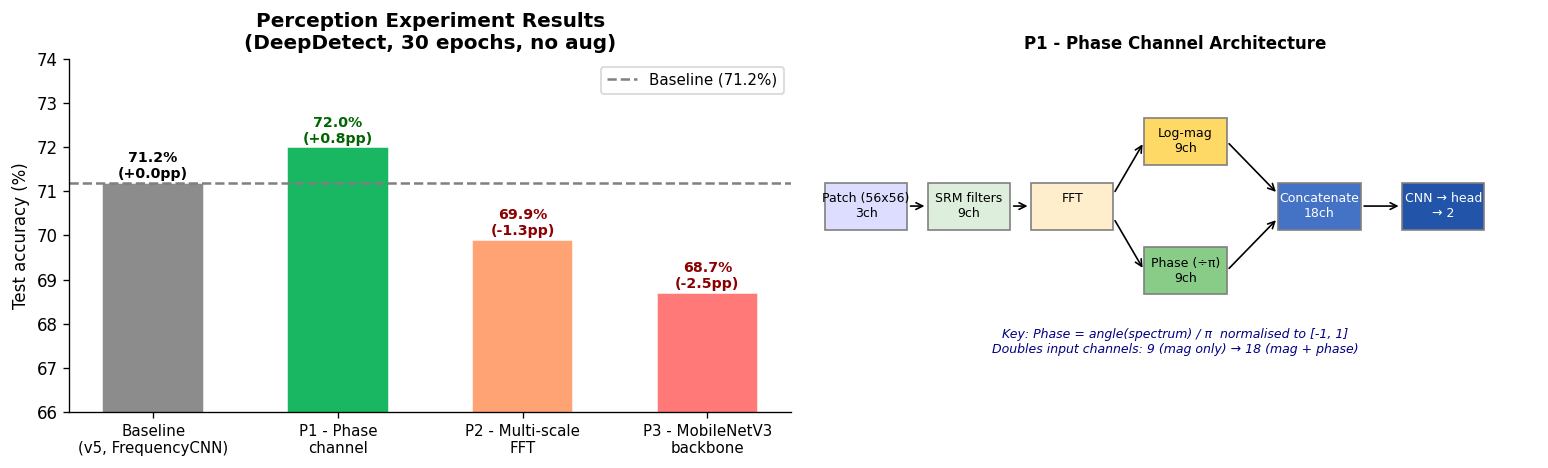

In [16]:
# Perception experiment results
perc_results = [
    ("Baseline\n(v5, FrequencyCNN)", 71.2, '#808080'),
    ("P1 - Phase\nchannel", 72.0, '#00B050'),
    ("P2 - Multi-scale\nFFT", 69.9, '#FF9966'),
    ("P3 - MobileNetV3\nbackbone", 68.7, '#FF6B6B'),
]
labels, accs, colors_p = zip(*perc_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(range(4), accs, color=colors_p, alpha=0.9, edgecolor='white', width=0.55)
ax.axhline(71.2, color='gray', linestyle='--', linewidth=1.5, label='Baseline (71.2%)')
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Perception Experiment Results\n(DeepDetect, 30 epochs, no aug)', fontweight='bold')
ax.set_ylim(66, 74)
ax.legend(fontsize=9)
for bar, v, (label, _, _) in zip(bars, accs, perc_results):
    delta = v - 71.2
    color = 'darkgreen' if delta > 0 else 'darkred' if delta < 0 else 'black'
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
            f'{v:.1f}%\n({delta:+.1f}pp)', ha='center', fontsize=8.5,
            fontweight='bold', color=color)
ax2 = axes[1]
ax2.axis('off')
ax2.set_xlim(0, 14)  # wider canvas
ax2.set_ylim(0, 6)
ax2.set_title('P1 - Phase Channel Architecture', fontweight='bold', fontsize=10)

# Box positions -- more spread out
boxes = {
    'Patch':    (1.0,  3.1),
    'SRM':      (3.0,  3.1),
    'FFT':      (5.0,  3.1),
    'LogMag':   (7.2,  4.2),
    'Phase':    (7.2,  2.0),
    'Concat':   (9.8,  3.1),
    'CNN':      (12.2, 3.1),
}
bw, bh = 1.6, 0.8

def draw_box(ax, cx, cy, label, color, fontcolor='black'):
    ax.add_patch(plt.Rectangle((cx - bw/2, cy - bh/2), bw, bh,
                                facecolor=color, edgecolor='gray', linewidth=1))
    ax.text(cx, cy, label, ha='center', va='center', fontsize=7.5, color=fontcolor)

draw_box(ax2, 1.0,  3.5, 'Patch (56x56)\n3ch',    '#DDDDFF')
draw_box(ax2, 3.0,  3.5, 'SRM filters\n9ch',       '#DDEEDD')
draw_box(ax2, 5.0,  3.5, 'FFT\n',                  '#FFEECC')
draw_box(ax2, 7.2,  4.6, 'Log-mag\n9ch',     '#FFD966')
draw_box(ax2, 7.2,  2.4, 'Phase (÷π)\n9ch',        '#88CC88')
draw_box(ax2, 9.8,  3.5, 'Concatenate\n18ch',      '#4472C4', 'white')
draw_box(ax2, 12.2, 3.5, 'CNN → head\n→ 2',        '#2255AA', 'white')

# Patch → SRM
ax2.annotate('', xy=(3.0 - bw/2, 3.5), xytext=(1.0 + bw/2, 3.5),
            arrowprops=dict(arrowstyle='->', color='black'))

# SRM → FFT
ax2.annotate('', xy=(5.0 - bw/2, 3.5), xytext=(3.0 + bw/2, 3.5),
            arrowprops=dict(arrowstyle='->', color='black'))

# FFT → Log-magnitude (up-right)
ax2.annotate('', xy=(7.2 - bw/2, 4.6), xytext=(5.0 + bw/2, 3.7),
            arrowprops=dict(arrowstyle='->', color='black'))

# FFT → Phase (down-right)
ax2.annotate('', xy=(7.2 - bw/2, 2.4), xytext=(5.0 + bw/2, 3.3),
            arrowprops=dict(arrowstyle='->', color='black'))

# Log-magnitude → Concatenate (down-right)
ax2.annotate('', xy=(9.8 - bw/2, 3.7), xytext=(7.2 + bw/2, 4.6),
            arrowprops=dict(arrowstyle='->', color='black'))

# Phase → Concatenate (up-right)
ax2.annotate('', xy=(9.8 - bw/2, 3.3), xytext=(7.2 + bw/2, 2.4),
            arrowprops=dict(arrowstyle='->', color='black'))

# Concatenate → CNN
ax2.annotate('', xy=(12.2 - bw/2, 3.5), xytext=(9.8 + bw/2, 3.5),
            arrowprops=dict(arrowstyle='->', color='black'))

ax2.text(7, 1.0, 'Key: Phase = angle(spectrum) / π  normalised to [-1, 1]\n'
         'Doubles input channels: 9 (mag only) → 18 (mag + phase)',
         ha='center', fontsize=7.5, style='italic', color='navy')
plt.tight_layout()
plt.show()


### 6.5 Hyperparameter Tuning: Finding the Right Balance

Before running DeepDetect experiments, we used Optuna with Tree-structured Parzen
Estimator (TPE) sampling to find the hyperparameter configuration that best balances
the spatial and frequency branches. 20 trials × 10 epochs each, run on convnext_base
with gating fusion.

**Search space:**
- `backbone_lr`: [1e-6, 5e-5] log-uniform - separate learning rate for the pretrained backbone
- `lr`: [5e-5, 5e-4] log-uniform - learning rate for frequency branch, fusion, and heads
- `freq_aux_weight`: [0.3, 1.0] - weight of the frequency auxiliary loss
- `diversity_weight`: [0.05, 0.3] - weight of the gate diversity penalty
- `gate_init_bias`: [0.0, 0.3] - initial bias to push the gate toward the frequency branch

**Tuning was done on convnext_base and the best config applied uniformly to all backbones.**
This ensures performance differences are attributable to backbone architecture rather
than differences in hyperparameter optimisation effort.

**Key tuning findings:**

The most important hyperparameter was `backbone_lr`. Failed trials (9, 16, 20)
consistently had very low backbone_lr (< 1×10⁻⁵) relative to their main lr, creating
an extreme imbalance. The frequency branch updated rapidly while the backbone barely
moved. This caused gradient conflicts and training instability.

Successful trials (11-14) converged on backbone_lr ≈ 4-5×10⁻⁵ with main lr ≈ 2.5-3×10⁻⁴,
giving a ratio of ~6:1. This ratio let the backbone fine-tune slowly while the frequency
branch and fusion module learned at a reasonable rate.

The `freq_aux_weight` converged around 0.5 - equal weight between the joint loss and the
frequency auxiliary loss. Higher values (> 0.7, seen in failed trials) over-emphasised
the frequency signal early in training before the gate had stabilised. Lower values
(< 0.35) led to frequency branch starvation.

`diversity_weight` converged to ~0.05-0.06 - much lower than the CIFAKE default of 0.1.
DeepDetect's higher-quality images produce more consistent frequency patterns, requiring
less diversity pressure to keep the gate active.

`gate_init_bias` ~0.2 consistently appeared in top trials. Initialising the gate to
slightly prefer the frequency branch prevents the spatial branch from immediately
dominating before the frequency branch has learned anything useful.

Note: tuning was done on the V1 pipeline (augmented patches) and these parameters
were applied to V2 experiments. The tuning still found valid parameters because it
correctly identified the backbone/frequency branch ratio as the critical variable.
This ratio is pipeline-independent.

See `tuning_deepdetect.ipynb` for the complete Optuna study with all 20 trial outputs.


## Balance Problem: Spatial vs Frequency Branch

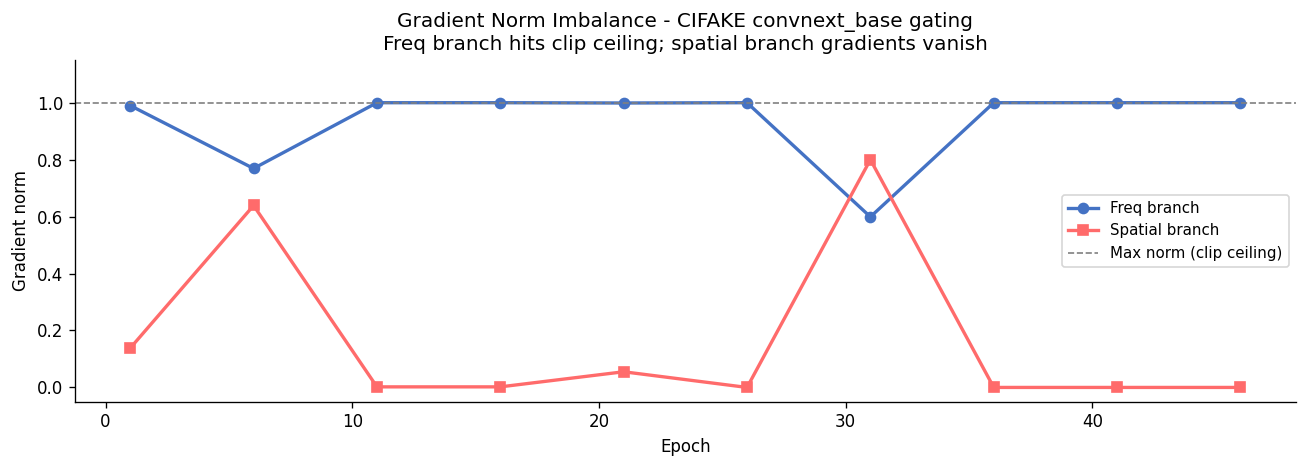

In [17]:
# Grad norm observations from CIFAKE convnext gating
grad_epochs = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
freq_norms   = [0.990, 0.769, 1.000, 1.000, 0.999, 1.000, 0.599, 1.000, 1.000, 1.000]
spatial_norms= [0.138, 0.639, 0.002, 0.002, 0.055, 0.000, 0.800, 0.000, 0.000, 0.000]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(grad_epochs, freq_norms,    'o-', color='#4472C4', label='Freq branch', linewidth=2)
ax.plot(grad_epochs, spatial_norms, 's-', color='#FF6B6B', label='Spatial branch', linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Max norm (clip ceiling)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gradient norm')
ax.set_title('Gradient Norm Imbalance - CIFAKE convnext_base gating\n'
             'Freq branch hits clip ceiling; spatial branch gradients vanish')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.show()

### 7.1 The Balance Problem and Our Mechanisms

The pretrained spatial backbone converges fast. By epoch 5-10 it generates small
parameter updates. The randomly initialised frequency branch continues generating large
gradients, consistently hitting the max_norm=1.0 clip ceiling. This imbalance persists
throughout training and limits the frequency branch's ability to contribute.

**Five mechanisms we used to address this:**

1. **Auxiliary loss on frequency branch (weight 0.5)** - direct gradient signal
   independent of the joint loss.

2. **Differential learning rates (backbone_lr=4.85e-5 vs lr=2.79e-4)** - the pretrained
   backbone uses a 6× smaller learning rate, slowing its convergence and reducing the
   imbalance window.

3. **Diversity regulariser** - penalises gate entropy below 2.0 nats, preventing early
   gate collapse to always-prefer-spatial.

4. **Optuna hyperparameter tuning** - 20 trials × 10 epochs systematically searched for
   the backbone_lr, freq_aux_weight, diversity_weight, and gate_init_bias combination
   that best balances the two branches. Best config: backbone_lr=4.85e-5, freq_aux=0.5,
   diversity=0.058, gate_bias=0.215.

5. **Gate initial bias (0.215)** - initialises the gate to slightly prefer the frequency
   branch, preventing early gate collapse to spatial-only.

Despite these mechanisms, the imbalance persists because the fundamental cause is
architectural. A pretrained backbone always converges faster than a randomly initialised
frequency CNN. The V2 pipeline partially addresses this by giving the frequency branch
a cleaner signal (no augmentation-corrupted patches) and reducing gradient noise.


## Key Findings Summary

**[F1] Delta increases with ViT patch size (CIFAKE)**
Among supervised ViT backbones, vit_b_16 and vit_b_32 show higher delta than convnext_base.
Larger patches create larger spectral blind spots, leaving more room for the frequency branch.

**[F2] Fine-tuning absorbs spectral information**
Fine-tuned delta: 0.0-1.4% (fused vs spatial-only). Frozen delta: 5.8-16.1% on CIFAKE
(fused vs spatial aux within the same frozen model).
When fine-tuned, backbones learn to encode spectral features, making the frequency branch redundant.
When frozen, neither branch can adapt, and the frequency branch contributes more meaningfully.

**[F3] Frozen delta increases with ViT patch size -- consistent across both datasets**
CIFAKE: convnext +5.8%, dino +10.1%, vit_b_16 +12.2%, vit_b_32 +16.1%.
DeepDetect V2: convnext +3.8%, vit_b_16 +7.2%, vit_b_32 +10.0%.
The patch size pattern holds across both datasets and resolutions -- a strong and consistent finding.
All frozen deltas are measured as fused accuracy minus spatial aux accuracy within the same frozen model.

**[F4] DINO captures frequency features via self-supervision**
DINO achieves 98.2% spatial-only accuracy despite its small patch size (8px).
Its self-supervised training objective preserves frequency-relevant features that supervised training discards.

**[F5] 38.9% of DeepDetect patches are dark corners (V1 pipeline)**
vs 1.0% on CIFAKE. The variance-only selector finds uninformative background regions on face images.
Direct cause of freq-only accuracy dropping from 94.5% (CIFAKE) to 58.2% (DeepDetect V1).

**[F6] Augmentation before patch selection destroys frequency artifacts**
Full aug on freq: 63.2% to spatial aug only: 74.2% (+11pp).
Fix: patch selected from the clean image (Chen et al. 2024), augmentation applied to full image for spatial branch only.

**[F7] Original cleaner beats deeper alternatives**
Original lightweight cleaner: 75.0% vs C1 deep filters: 73.0%.
More capacity leads to overfitting on clean patches.

**[F8] Gate never collapsed across all experiments**
All entropy values >> 0.3 nats threshold throughout training.
Gate adapts genuinely, with consistently higher entropy when the backbone is frozen.

**[F9] Gating not clearly better than scalar or joint-only**
Differences between fusion modes are within noise margins.
The balance problem limits gating advantage in the fine-tuned setting.
Most valuable in the frozen or cross-domain setting where per-image variation is highest.

**[F10] V2 pipeline improves frequency signal but not fine-tuned delta**
Freq-only auxiliary accuracy: 58.7% (V1) to 72-73% (V2).
Fine-tuned delta remains near zero. The fine-tuning absorption problem persists regardless of pipeline quality.


## Limitations and Future Work

### Limitations

**1. Patch selection is domain-specific**
The v5 skin-tone selector works well on face-dominated datasets but fails on non-face images where there are no skin-tone regions to detect. The v2 brightness-filtered selector is more general but less effective on DeepDetect. A truly general patch selector remains an open problem.

**2. Gradient imbalance persists despite five mitigation mechanisms**
Auxiliary loss, differential learning rates, diversity regulariser, Optuna tuning, and gate initial bias all reduce but do not eliminate the imbalance. An architectural fix: separate optimisers for the two branches might be needed to fully address this.

**3. DeepDetect ceiling effect**
Spatial-only convnext_base achieves 96.1% on DeepDetect, leaving very little room for the frequency branch to contribute in fine-tuned mode. The dataset may be too easy for a strong pretrained backbone, making it an insufficient benchmark for frequency branch evaluation.

**4. No cross-generator evaluation**
DeepDetect does not provide per-generator labels. The generalisation hypothesis that the frequency branch helps when the spatial branch encounters unseen generators cannot be directly verified with the current data.

**5. Single-run results**
All experiments were run once. Variance across seeds is not quantified. Results may vary by ±0.3-0.5% across runs, which is within the margin of the differences between fusion modes.

**6. vit_b_16 anomaly on DeepDetect V2**
The joint_only experiment shows a negative delta of -3.6% (91.1% vs spatial-only 94.7%). The cause is not fully understood. It may require more training epochs, a different learning rate, or further investigation into how the frequency auxiliary loss interacts with this backbone at 224×224.


### Future Work

**1. GenImage - cross-generator evaluation**
GenImage provides 8 generators with per-generator labels (Midjourney, Stable Diffusion, DALL-E, etc.). A held-out generator experiment would directly test whether the frequency branch improves generalisation to unseen generators, validating the frozen ablation hypothesis.

**2. Semantically guided patch selection**
Replace the HSV skin detector with a lightweight face parser (e.g. BiSeNet) to identify smooth facial regions such as the forehead and cheek. More reliable than HSV across skin tones and lighting conditions.

**3. Dual-stream optimisation**
Use separate optimisers for the spatial and frequency branches, allowing each to have its own learning rate schedule and gradient scaling. This addresses the imbalance at the architectural level rather than through loss weighting heuristics.

**4. Calibrated augmentations**
Replace aggressive training augmentations with lighter ones tuned to real-world degradation levels - JPEG quality 85-95 rather than 70-90, for example. The goal is robustness without destroying the frequency signal the branch is trying to detect.

**5. Chen et al. ESSP enhancement module**
Compare our original lightweight cleaner to the Enhanced SSP module from Chen et al. (2024), which was specifically designed for handling degraded test images in the frequency pipeline.

**6. Longer training for vit_b_16 on DeepDetect**
Investigate whether the negative delta resolves with 50+ epochs or a backbone-specific learning rate, and determine whether it is a training stability issue or a fundamental incompatibility between vit_b_16 patch size and the DeepDetect image distribution.

## Complete Results Table

In [18]:
# Full results table from CSV - includes final vit_b_16 gating_frozen result
print("Complete Results - All Experiments")
print(f"Total: {len(df)} results")
print()
display_cols = ['experiment_name', 'dataset', 'backbone', 'fusion', 'frozen',
                'accuracy', 'auc_roc', 'f1', 'gate_entropy']
print(df[display_cols].to_string(index=False))


Complete Results - All Experiments
Total: 46 results

                  experiment_name    dataset      backbone     fusion  frozen  accuracy  auc_roc     f1  gate_entropy
               freq_only_baseline     cifake convnext_base     gating   False    0.9436   0.9871 0.9446        0.0000
       convnext_base_spatial_only     cifake convnext_base joint_only   False    0.9872   0.9983 0.9872        0.0000
         convnext_base_joint_only     cifake convnext_base joint_only   False    0.9876   0.9985 0.9876        0.0000
             convnext_base_scalar     cifake convnext_base     scalar   False    0.9868   0.9985 0.9868        0.0000
             convnext_base_gating     cifake convnext_base     gating   False    0.9888   0.9987 0.9888        0.9590
      convnext_base_gating_frozen     cifake convnext_base     gating    True    0.9653   0.9948 0.9654        2.7965
            vit_b_32_spatial_only     cifake      vit_b_32 joint_only   False    0.9464   0.9879 0.9464        0.0000
  

In [19]:
# Summary statistics from CSV
print("\nSummary Statistics")
print("="*55)
cifake_df = df[df.dataset == 'cifake']
dd_v1_df  = df[df.experiment_name.str.startswith('dd_convnext')]
dd_v2_df  = df[df.experiment_name.str.startswith('dd_v2')]

print(f"Best CIFAKE accuracy:              {cifake_df.accuracy.max()*100:.2f}%")
print(f"Best DeepDetect V1 accuracy:       {dd_v1_df.accuracy.max()*100:.2f}%")
print(f"Best DeepDetect V2 accuracy:       {dd_v2_df.accuracy.max()*100:.2f}%")
print(f"Best freq-only standalone:         75.0% (v5 + cleaner + clean patch)")
print(f"Freq-only V1 baseline (CIFAKE):    {df[df.experiment_name=='freq_only_baseline'].accuracy.values[0]*100:.1f}%")
print()
print("Frozen Ablation Summary (delta = fused - spatial_aux within same frozen model):")
print()
print("  CIFAKE:")
cifake_frozen = [
    ('convnext_base', 96.5, 5.8),
    ('dino_vits8',    96.9, 10.1),
    ('vit_b_16',      94.5, 12.2),
    ('vit_b_32',      94.5, 16.1),
]
for bb, acc, delta in cifake_frozen:
    print(f"    {bb:<18} joint={acc:.1f}%  delta={delta:+.1f}%")
print()
print("  DeepDetect V2:")
dd_v2_frozen = [
    ('convnext_base', 90.6, 3.8),
    ('dino_vits8',    89.7, 7.9),
    ('vit_b_16',      89.5, 7.2),
    ('vit_b_32',      85.0, 10.0),
]
for bb, acc, delta in dd_v2_frozen:
    print(f"    {bb:<18} joint={acc:.1f}%  delta={delta:+.1f}%")


Summary Statistics
Best CIFAKE accuracy:              98.88%
Best DeepDetect V1 accuracy:       97.02%
Best DeepDetect V2 accuracy:       97.18%
Best freq-only standalone:         75.0% (v5 + cleaner + clean patch)
Freq-only V1 baseline (CIFAKE):    94.4%

Frozen Ablation Summary (delta = fused - spatial_aux within same frozen model):

  CIFAKE:
    convnext_base      joint=96.5%  delta=+5.8%
    dino_vits8         joint=96.9%  delta=+10.1%
    vit_b_16           joint=94.5%  delta=+12.2%
    vit_b_32           joint=94.5%  delta=+16.1%

  DeepDetect V2:
    convnext_base      joint=90.6%  delta=+3.8%
    dino_vits8         joint=89.7%  delta=+7.9%
    vit_b_16           joint=89.5%  delta=+7.2%
    vit_b_32           joint=85.0%  delta=+10.0%
